<a href="https://colab.research.google.com/github/minoshim/Num_Analysis/blob/main/FDS/Py/Adv/fds_adv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Functions
def init(x, f, xoff, dx, lx):  # Initialize
    nx = len(f)
    i = np.arange(nx)
    x[:] = (i + 0.5 - xoff) * dx - 0.5 * lx
    f[:] = np.where((nx // 4 < i) & (i < 3 * nx // 4), 1.0, 0.0)
    # f[:]=np.exp(-(x[:]*x[:])/(16*dx*dx))


def bc1d(f, xoff, dnx):  # Boundary condition
    nx = len(f)
    if dnx == 0:
        f[:xoff] = f[nx - 2 * xoff : nx - xoff]
        f[nx - xoff :] = f[xoff : 2 * xoff]
    elif abs(dnx) == 1:
        f[:xoff] = dnx * f[xoff : 2 * xoff][::-1]
        f[nx - xoff :] = dnx * f[nx - 2 * xoff : nx - xoff][::-1]


def ftcs(f, v, dt, dx, xoff):  # FTCS scheme
    nx = len(f)
    nu = v * dt / dx  # Courant number
    df = np.zeros_like(f)
    df[1:-1] = 0.5 * (f[2:] - f[:-2])
    f[xoff : nx - xoff] -= nu * df[xoff : nx - xoff]


def upwd(f, v, dt, dx, xoff):  # Upwind scheme
    nx = len(f)
    nu = v * dt / dx  # Courant number
    sgnv = np.sign(v)
    df = np.zeros_like(f)
    df[1:-1] = 0.5 * ((1 + sgnv) * (f[1:-1] - f[:-2]) + (1 - sgnv) * (f[2:] - f[1:-1]))
    f[xoff : nx - xoff] -= nu * df[xoff : nx - xoff]


def lw(f, v, dt, dx, xoff):  # Lax-Wendroff scheme
    nx = len(f)
    nu = v * dt / dx  # Courant number
    df = np.zeros_like(f)
    df[1:-1] = -0.5 * nu * (f[2:] - f[:-2]) + 0.5 * nu**2 * (
        f[2:] - 2 * f[1:-1] + f[:-2]
    )
    f[xoff : nx - xoff] += df[xoff : nx - xoff]


def csl3rd(f, v, dt, dx, xoff):  # 3rd-order conservative SL scheme
    nx = len(f)
    nu = v * dt / dx
    sgnv = np.sign(v)
    flux = np.zeros_like(f)
    c0l = (-f[0:-3] + 5 * f[1:-2] + 2 * f[2:-1]) / 6.0
    c0r = (-f[3:] + 5 * f[2:-1] + 2 * f[1:-2]) / 6.0
    c1 = f[2:-1] - f[1:-2]
    c2l = (f[0:-3] - 2 * f[1:-2] + f[2:-1]) * 0.5
    c2r = (f[3:] - 2 * f[2:-1] + f[1:-2]) * 0.5
    ftl = c0l + nu * (-c1 * 0.5 + c2l * nu / 3.0)
    ftr = c0r + nu * (-c1 * 0.5 + c2r * nu / 3.0)
    flux[2:-1] = 0.5 * ((1 + sgnv) * ftl + (1 - sgnv) * ftr)
    f[xoff : nx - xoff] -= nu * (
        flux[xoff + 1 : nx - xoff + 1] - flux[xoff : nx - xoff]
    )

In [138]:
def main(f, t, tmax, method, v, dt, dx, xoff):
    while t < tmax:
        bc1d(f, xoff, 0)
        if method == "ftcs":
            ftcs(f, v, dt, dx, xoff)
        elif method == "upwd":
            upwd(f, v, dt, dx, xoff)
        elif method == "lw":
            lw(f, v, dt, dx, xoff)
        elif method == "csl3rd":
            csl3rd(f, v, dt, dx, xoff)
        else:
            raise ValueError("Invalid method. Choose 'ftcs' or 'upwd'.")
        t += dt
    return t

In [139]:
# User-set parameters
## Spatial grid
xoff = 2
xmesh = 100
nx = xmesh + 2 * xoff

lx = 1.0  # Domain size
v = 1.0  # Advection velocity
cfl = 0.5  # CFL number
tmax = 0.15  # Maximum simulation time
# End of user-set parameters

# Grid width
dx = lx / xmesh
dt = np.abs(cfl * dx / v)
# Variables
x = np.zeros(nx)
f = np.zeros(nx)

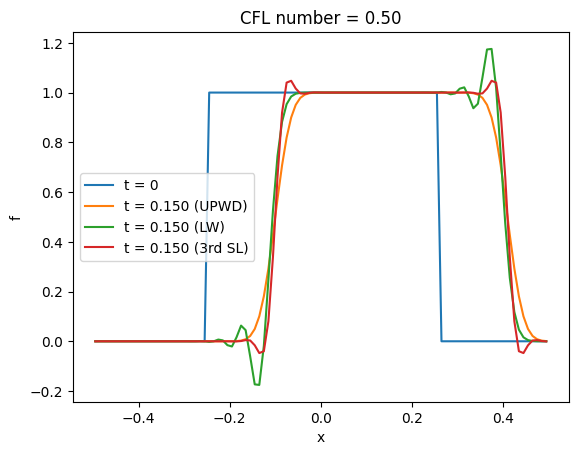

In [140]:
init(x, f, xoff, dx, lx)
plt.plot(x[xoff:-xoff], f[xoff:-xoff], label="t = 0")

t_ftcs = main(f, 0, tmax, "ftcs", v, dt, dx, xoff)
# plt.plot(x[xoff:-xoff], f[xoff:-xoff], label=f"t = {t_ftcs:.3f} (FTCS)")

init(x, f, xoff, dx, lx)
t_upwd = main(f, 0, tmax, "upwd", v, dt, dx, xoff)
plt.plot(x[xoff:-xoff], f[xoff:-xoff], label=f"t = {t_upwd:.3f} (UPWD)")

init(x, f, xoff, dx, lx)
t_lw = main(f, 0, tmax, "lw", v, dt, dx, xoff)
plt.plot(x[xoff:-xoff], f[xoff:-xoff], label=f"t = {t_lw:.3f} (LW)")

init(x, f, xoff, dx, lx)
t_csl3rd = main(f, 0, tmax, "csl3rd", v, dt, dx, xoff)
plt.plot(x[xoff:-xoff], f[xoff:-xoff], label=f"t = {t_csl3rd:.3f} (3rd SL)")

plt.title(f"CFL number = {cfl:.2f}")
plt.xlabel("x")
plt.ylabel("f")
plt.legend()
plt.show()